In [2]:
from bccr import SW 
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
df = SW(
    compra=317,
    venta=318,
    FechaInicio="01/01/1983",
    FechaFinal="31/12/2025"
)
#Separación entre los distintos régimenes usados:

df_minidevaluaciones = df.loc[:"2006-10-16"]
df_bandas = df.loc["2006-10-17":"2015-01-29"]
df_flotacion = df.loc["2015-01-30":]

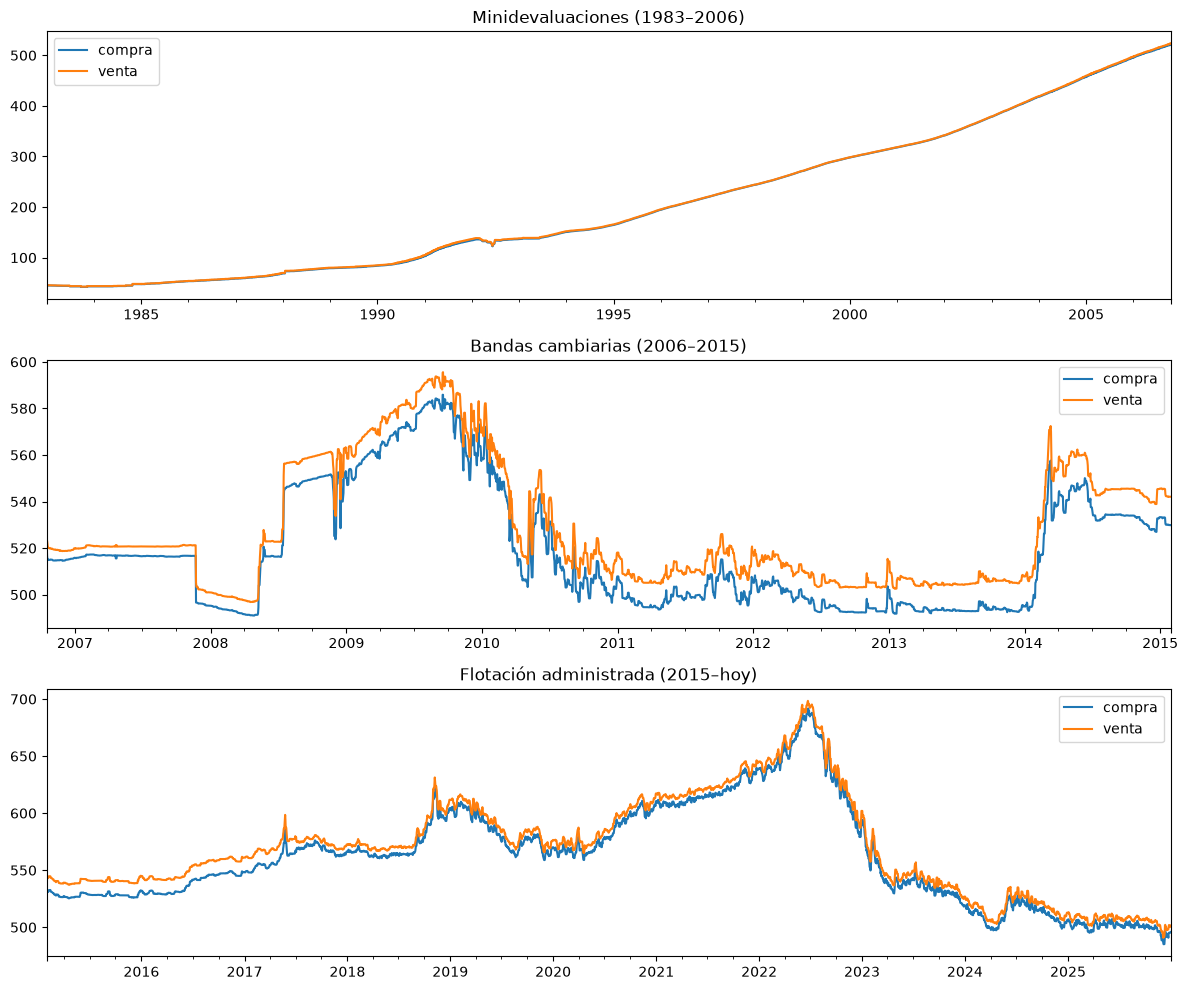

In [4]:
#Graficación para ver diferencias entre los sistemas
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

df_minidevaluaciones.plot(ax=axes[0], title="Minidevaluaciones (1983–2006)")
df_bandas.plot(ax=axes[1], title="Bandas cambiarias (2006–2015)")
df_flotacion.plot(ax=axes[2], title="Flotación administrada (2015–hoy)")

plt.tight_layout()
plt.show()

## Regímenes cambiarios en Costa Rica

El tipo de cambio USD/CRC no se ha determinado siempre de la misma forma. Desde 1983, Costa Rica ha pasado por tres regímenes cambiarios distintos, cada uno con una dinámica de precios diferente. Esto es relevante para el modelado porque cada régimen tiene un mecanismo distinto de formación de precios, lo cual afecta la volatilidad, la predictibilidad y la validez de comparar datos entre períodos.

### 1. Minidevaluaciones / paridad ajustada (1983 – 16/10/2006)

El BCCR fijaba una devaluación diaria pequeña y casi constante, buscando igualar el diferencial entre la inflación local y la externa. El tipo de cambio no lo determinaba el mercado, sino una regla predecible del Banco Central. Como resultado, la serie en este período tiene una tendencia casi lineal y muy poca volatilidad de corto plazo — cualquier modelo, incluso trivial, "predice" bien este período, por lo que no es representativo de un problema de predicción financiera real.

### 2. Bandas cambiarias (17/10/2006 – 29/01/2015)

El BCCR estableció un techo y un piso dentro de los cuales el tipo de cambio podía moverse libremente según oferta y demanda en el mercado (MONEX). El Banco intervenía automáticamente comprando o vendiendo dólares cuando el precio tocaba alguno de esos límites. Esto introduce una dinámica de mercado real, pero con una cota artificial: la volatilidad está comprimida por los límites de la banda, y el comportamiento cerca de los bordes no es "libre" sino resultado de la intervención del banco.

### 3. Flotación administrada (30/01/2015 – actualidad)

El BCCR eliminó los límites fijos de la banda. El tipo de cambio se determina principalmente por oferta y demanda en MONEX, aunque el Banco Central puede intervenir de forma discrecional (no automática) para suavizar movimientos abruptos. Es el régimen más parecido a un mercado libre de los tres, y por lo tanto el que ofrece el reto de predicción más realista y relevante para un modelo de series de tiempo financiero.

In [1]:
#Voy a guardar en un .csv cada conjunto de datos por separado
df_minidevaluaciones.to_csv('modeloMinidevaluaciones.csv', index=False)
df_bandas.to_csv('modeloBandas.csv', index=False)
df_flotacion.to_csv('modeloFlotacion.csv', index=False )

NameError: name 'df_minidevaluaciones' is not defined

## Uso de Covariables
Además de estos datos se está considerando el uso de covariales, entre las cuales hay propuestas interesantes como:

### Tasa Básica Pasiva  

Es la tasa de interés promedia que pagan los bancos de Costa Rica por captar ahorros en colones. Si esas tasas suben mucho, se vuelve más atractivo ahorrrar en colones que en dólares, por lo que impulsa al tipo de cambio "hacia abajo", es decir más demanda en colones.

### Tasa Política Monetaria (TPM)

Es una tasa fijada por el BCCR como referencia para toda la economía. Si esta tasa sube o baja por alguna razón, sería la señal más directa sobre su postura sobre la inflación y por ende sobre el tipo de cambio. 

### Inflación - IPC 

El índice de precios del consumidor mensual, esto importa porque la paridad del poder adquisitivo que dice que en el largo plazo, monedas de países con más inflación tiendedn a depreciarse frente a las de menor inflación.

### IMAE (índice Mensual de Actividad Económica)

Es una especie de PIB aproximado, mide qué tan activa está la economía, más actividad económica implica más comercio exterior generalmente, lo cual mueve la oferta y demanda de los dólares.

### Reservas internacionales Netas

Cuántos dólares tienen guardados el BCCR, esto es relevante porque si dichas reservas llegaran a bajar mucho, implicaría que el banco tiene menos poder para intervenir y defender el tipo de cambio, lo cual puede generar expectativas de depreciación. 

### Volumen Negociado en MONEX

Cuántos dólare se compran y venden por día en el mercado mayorista. Es una medida de liquidez, días de bajo volumen pueden tener movimientos de precio más imprevisibles o inestables. 

In [6]:
print(SW.buscar("tasa básica pasiva"))
print(SW.buscar("tasa de política monetaria"))
print(SW.buscar("índice de precios al consumidor"))
print(SW.buscar("IMAE"))
print(SW.buscar("reservas internacionales netas"))
print(SW.buscar("MONEX"))

Descargando catálogo de indicadores..., por favor espere.
                                          Nombre  \
Código                                             
423     Tasa básica pasiva calculada por el BCCR   
430               Tasa básica pasiva, fin de mes   
19519     Tasa básica pasiva total peso relativo   
19583     Tasa básica pasiva total Tasa Promedio   
19654          Tasa básica pasiva (Con Redondeo)   

                                     Descripción Periodicidad    Cuadro  
Código                                                                   
423     Tasa básica pasiva calculada por el BCCR       Diaria       475  
430     Tasa básica pasiva calculada por el BCCR      Mensual       737  
19519     Tasa básica pasiva total peso relativo      Semanal       334  
19583     Tasa básica pasiva total Tasa Promedio      Semanal       334  
19654          Tasa básica pasiva (Con Redondeo)      Semanal  334, 837  
Empty DataFrame
Columns: [Nombre, Descripción, Periodicidad

In [7]:
#script generado por Claude AI
INDICADORES = {
    "tipo_cambio_compra":        317,
    "tipo_cambio_venta":         318,
    "tasa_basica_pasiva":        423,
    "reservas_internacionales":  5970,
    "volumen_monex":             3446,
    "ipc":                       98405,
    "imae":                      87703,
}

FECHA_INICIO = "17/10/2006"
FECHA_FINAL  = "31/12/2025"

CARPETA_SALIDA = "datos_bccr_crudos"
os.makedirs(CARPETA_SALIDA, exist_ok=True)

In [8]:
#script generado por Claude AI
for nombre, codigo in INDICADORES.items():
    print(f"Descargando: {nombre} (código {codigo})...")

    df_individual = SW(
        **{nombre: codigo},
        FechaInicio=FECHA_INICIO,
        FechaFinal=FECHA_FINAL
    )

    ruta_salida = os.path.join(CARPETA_SALIDA, f"{nombre}.csv")
    df_individual.to_csv(ruta_salida)

    print(f"  -> Guardado en {ruta_salida} ({len(df_individual)} filas)\n")

Descargando: tipo_cambio_compra (código 317)...
  -> Guardado en datos_bccr_crudos/tipo_cambio_compra.csv (7016 filas)

Descargando: tipo_cambio_venta (código 318)...
  -> Guardado en datos_bccr_crudos/tipo_cambio_venta.csv (7016 filas)

Descargando: tasa_basica_pasiva (código 423)...
  -> Guardado en datos_bccr_crudos/tasa_basica_pasiva.csv (7016 filas)

Descargando: reservas_internacionales (código 5970)...
  -> Guardado en datos_bccr_crudos/reservas_internacionales.csv (7016 filas)

Descargando: volumen_monex (código 3446)...
  -> Guardado en datos_bccr_crudos/volumen_monex.csv (6606 filas)

Descargando: ipc (código 98405)...
  -> Guardado en datos_bccr_crudos/ipc.csv (231 filas)

Descargando: imae (código 87703)...
  -> Guardado en datos_bccr_crudos/imae.csv (228 filas)



In [9]:
import pandas as pd
df_ipc = pd.read_csv("datos_bccr_crudos/ipc.csv", index_col=0, parse_dates=True)
df_ipc.head()

,ipc
2006-10-31,0.191334
2006-11-30,1.014444
2006-12-31,1.017507
2007-01-31,0.952205
2007-02-28,0.353333


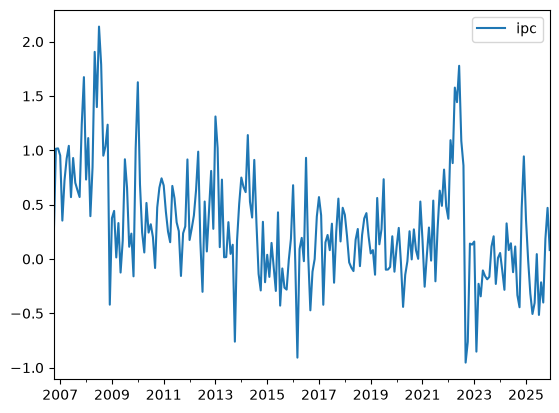

In [11]:
df_ipc.plot();

Idea extra, un modelo que lea titulares o peridicos y usarlo de transformador y generar una o 2 variables externas para incluirlas.

In [12]:
!pip install plotnine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.7 MB/s  0:00:00m ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 13.6 MB/s  0:00:004.6 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [plotnine]━━ 7/8 [plotnine]ls]


In [13]:
from plotnine import *

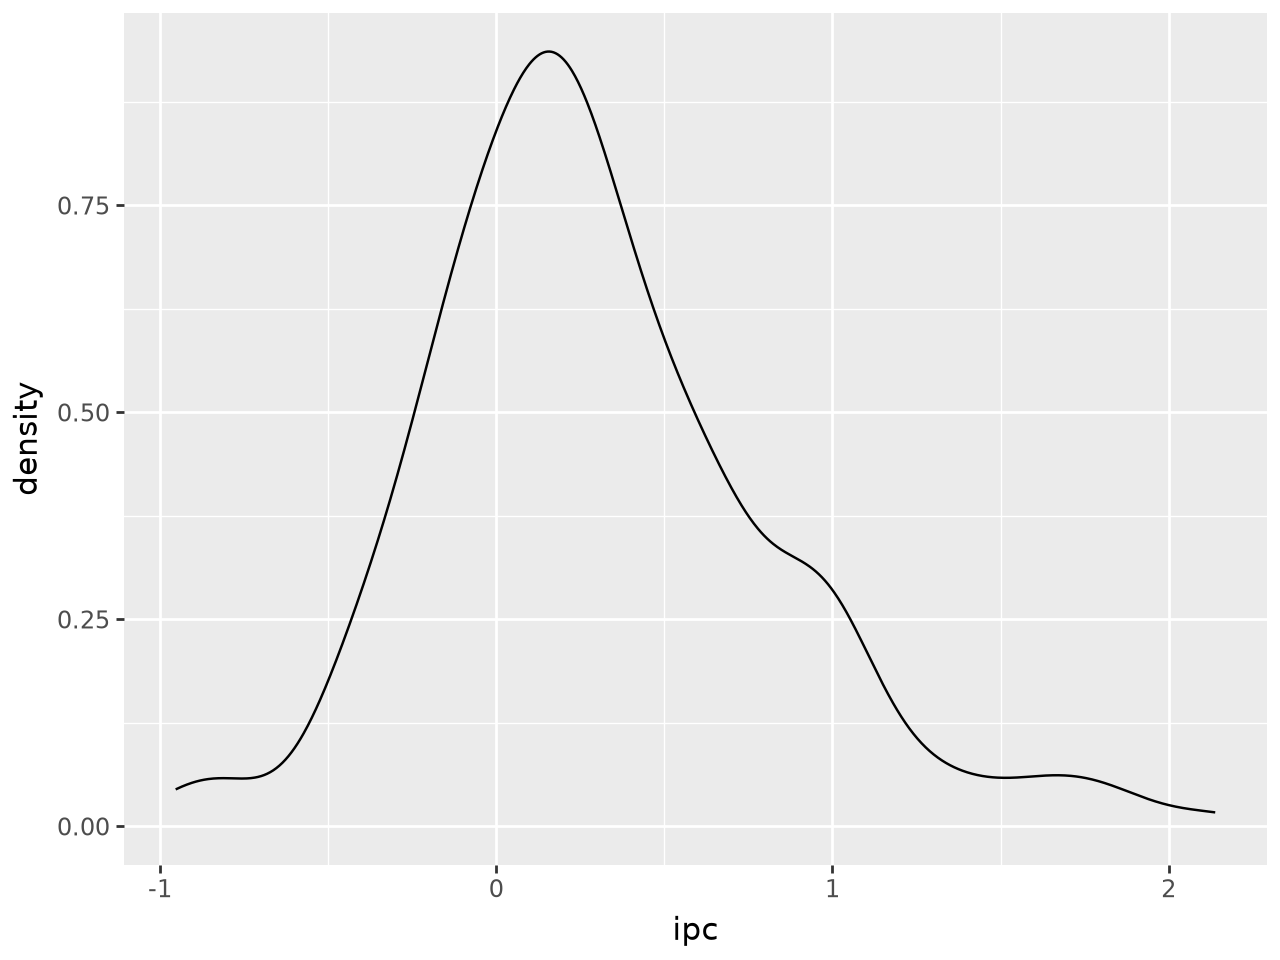

In [14]:
ggplot(df_ipc, aes(x='ipc'))+geom_density()